In [7]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from plant_shape_analysis.data_preprocessing.process_gt_TrackPlant3D  import custom_trimmed_poisson

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get GT data

We review the manual quality assesment of the dense point cloud data to only compute traits for the good leaves for now

In [10]:
base_path = Path("../data/TrackPlant3D")
qa_csv = base_path / "dense_leaves" / "dense_leaves_quality_assesment.csv"
df = pd.read_csv(qa_csv, delimiter=';')
df.head()

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,1,1,1_maize_control_plant1_D00_leaf2_dense,maize,control,1,0,2,bad,large holes
2,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
3,3,1,2_maize_control_plant1_D01_leaf2_dense,maize,control,1,1,2,bad,poor segmentation
4,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN


In [9]:
good_leaves = df.loc[df['quality'] == 'good'].reset_index(drop=True)
good_leaves

,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN
5,10,0,5_maize_control_plant1_D04_leaf1_dense,maize,control,1,4,1,good,NaN
6,11,1,5_maize_control_plant1_D04_leaf2_dense,maize,control,1,4,2,good,NaN
7,12,2,5_maize_control_plant1_D04_leaf3_dense,maize,control,1,4,3,good,"small noise - apply SOR(nb=50,std=10)"
8,13,0,6_maize_control_plant1_D05_leaf1_dense,maize,control,1,5,1,good,NaN
9,14,1,6_maize_control_plant1_D05_leaf2_dense,maize,control,1,5,2,good,"small noise - apply SOR(nb=20,std=15)"


In [13]:
# Load the JSON data with surface area measurements
json_path = base_path / "dense_leaf_meshes" / "maize" / "processing_results.json"
with open(json_path, 'r') as f:
    surface_data = json.load(f)

# Create a dictionary to map filenames to surface area
surface_dict = {}
for entry in surface_data:
    # Extract filename without extension
    filename = entry['leaf_file'].replace('.ply', '')
    surface_dict[filename] = entry['surface_area']

# Add surface area column to good_leaves DataFrame
good_leaves['surface_area_mm2'] = good_leaves['file_name'].map(surface_dict)

# Filter out rows where surface area data is missing
plot_df = good_leaves.dropna(subset=['surface_area_mm2']).copy()

print(f"Found surface area data for {len(plot_df)} out of {len(good_leaves)} good leaves")
plot_df.head()

Found surface area data for 32 out of 32 good leaves


,dense_leaf_id,leaf_sequence_id,file_name,crop,treatment,plant,day,leaf,quality,comment,surface_area_mm2
0,0,0,1_maize_control_plant1_D00_leaf1_dense,maize,control,1,0,1,good,NaN,495.334281
1,2,0,2_maize_control_plant1_D01_leaf1_dense,maize,control,1,1,1,good,NaN,487.358933
2,4,0,3_maize_control_plant1_D02_leaf1_dense,maize,control,1,2,1,good,NaN,480.708181
3,7,0,4_maize_control_plant1_D03_leaf1_dense,maize,control,1,3,1,good,NaN,483.115097
4,8,1,4_maize_control_plant1_D03_leaf2_dense,maize,control,1,3,2,good,NaN,1099.338830


Plants: [np.int64(1), np.int64(2)]
Leaf numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


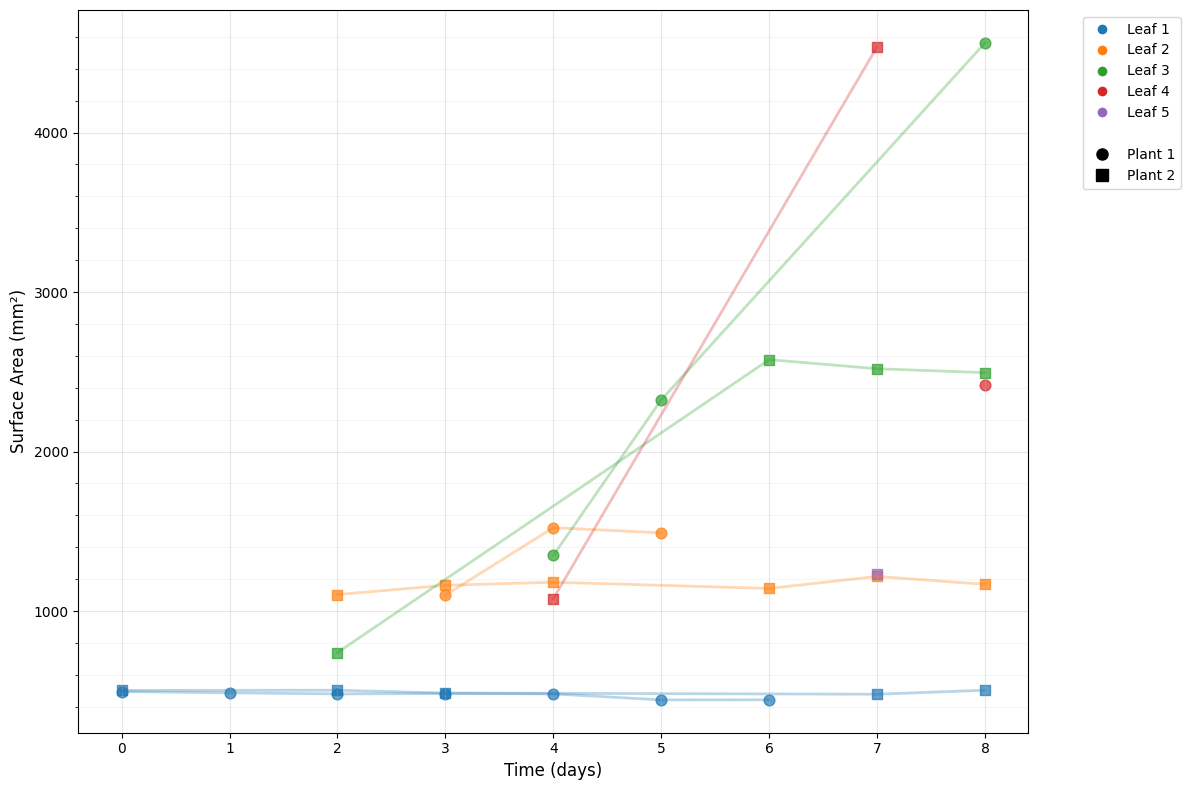


Summary by leaf number:
Leaf 1: 12 measurements, Area range: 443.3 - 503.9 mm²
Leaf 2: 9 measurements, Area range: 1099.3 - 1522.9 mm²
Leaf 3: 7 measurements, Area range: 739.7 - 4562.6 mm²
Leaf 4: 3 measurements, Area range: 1077.5 - 4537.7 mm²
Leaf 5: 1 measurements, Area range: 1230.4 - 1230.4 mm²


In [22]:
# Check if we have data to plot
if len(plot_df) == 0:
    print("No data available for plotting. Please check the data extraction step above.")
else:
    # Create the plot with different markers for plants and colors for leaf numbers
    plt.figure(figsize=(12, 8))

    # Define colors for each leaf number (use enough colors for all possible leaf numbers)
    colors = plt.cm.tab10(np.arange(10))  # Use tab10 colormap for distinct colors
    markers = ['o', 's', '^']  # Different markers for different plants

    # Get unique plants and leaf numbers
    plants = sorted(plot_df['plant'].unique())
    leaf_numbers = sorted(plot_df['leaf'].unique())

    print(f"Plants: {plants}")
    print(f"Leaf numbers: {leaf_numbers}")

    # Plot each combination of plant and leaf number
    for i, plant in enumerate(plants):
        for leaf_num in leaf_numbers:
            # Filter data for this plant and leaf number
            data_subset = plot_df[(plot_df['plant'] == plant) & (plot_df['leaf'] == leaf_num)]
            
            if len(data_subset) > 0:
                plt.scatter(data_subset['day'], data_subset['surface_area_mm2'], 
                           color=colors[leaf_num-1], marker=markers[i], s=60,
                           label=f'Plant {plant}, Leaf {leaf_num}' if i == 0 else '',  # Only label once per leaf
                           alpha=0.7)
                
                # Connect points for the same leaf within a plant with lines
                if len(data_subset) > 1:
                    sorted_data = data_subset.sort_values('day')
                    plt.plot(sorted_data['day'], sorted_data['surface_area_mm2'], 
                            color=colors[leaf_num-1], linestyle='-', alpha=0.3, linewidth=2)

    plt.xlabel('Time (days)', fontsize=12)
    plt.ylabel('Surface Area (mm²)', fontsize=12)
    #plt.title('Leaf Surface Area Over Time by Leaf Number\n(Good Quality Leaves Only)', fontsize=14)
    
    # Add minor ticks on y-axis
    from matplotlib.ticker import AutoMinorLocator
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
    plt.grid(True, alpha=0.3)
    plt.grid(True, which='minor', alpha=0.1)

    # Create custom legend
    legend_elements = []

    # Add leaf number colors to legend
    for leaf_num in leaf_numbers:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor=colors[leaf_num-1], markersize=8,
                                     label=f'Leaf {leaf_num}'))

    # Add plant markers to legend
    legend_elements.append(Line2D([0], [0], marker='', color='w', label=''))  # Spacer
    for i, plant in enumerate(plants):
        legend_elements.append(Line2D([0], [0], marker=markers[i], color='k', 
                                     markersize=8, linestyle='None',
                                     label=f'Plant {plant}'))

    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save the figure
    Path("../figures").mkdir(parents=True, exist_ok=True)
    plt.savefig("../figures/trackplant3D_gt_leaves_area_timeseries.pdf", dpi=300, bbox_inches='tight')
    
    plt.show()


    # Print summary statistics
    print("\nSummary by leaf number:")
    for leaf_num in leaf_numbers:
        data_subset = plot_df[plot_df['leaf'] == leaf_num]
        if len(data_subset) > 0:
            print(f"Leaf {leaf_num}: {len(data_subset)} measurements, "
                  f"Area range: {data_subset['surface_area_mm2'].min():.1f} - {data_subset['surface_area_mm2'].max():.1f} mm²")